In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import MDAnalysis as mda
from MDAnalysis.analysis import contacts,distances
import io
from PIL import Image
from collections import defaultdict
import itertools
import pickle
import seaborn as sns
import glob
import matplotlib.ticker as ticker

In [2]:
# =========================
# USER INPUT
# =========================
pdb_file = "/Users/achakrab/Documents/asn/trj/fas/last_frame.pdb"
xtc_file = "/Users/achakrab/Documents/asn/trj/fas/pro_lig.xtc"
#ligand_resname = "*"       # change if needed
contact_cutoff = 3.0          # Å
frame_skip = 10              # ← skip every 100th frame

In [3]:
# =========================
# LOAD SYSTEM
# =========================
u = mda.Universe(pdb_file, xtc_file)

protein = u.select_atoms("protein")
#ligand = u.select_atoms(f"resname {ligand_resname}")

ligand = u.select_atoms("not protein")


residues = protein.residues
n_res = len(residues)

/Users/achakrab/miniconda3/envs/pyemma/lib/python3.9/site-packages/MDAnalysis/topology/PDBParser.py:331: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using MDAnalysis.topology.guessers.
  warnings.warn("Element information is missing, elements attribute "


In [4]:
# =========================
# BUILD CONTACT SERIES
# =========================
contact_series = []

for ts in u.trajectory[::frame_skip]:
    contacts = []
    for i, res in enumerate(residues):
        res_atoms = res.atoms
        min_dist = mda.lib.distances.distance_array(res_atoms.positions, ligand.positions).min()
        if min_dist < contact_cutoff:
            contacts.append(res.resid)
    contact_series.append(set(contacts))


In [5]:
# =========================
# TRIPLET TRANSITION EXTRACTION
# =========================
from collections import defaultdict
from itertools import tee

def pairwise(iterable):
    a, b = tee(iterable)
    next(b, None)
    return zip(a, b)

# Step 1: Filter to only contact sets of size 3
triplet_contact_series = [c for c in contact_series if len(c) == 3]

# Step 2: Count transitions between sorted triplets
triplet_transitions = defaultdict(int)
for c1, c2 in pairwise(triplet_contact_series):
    if c1 != c2:
        triplet_transitions[(tuple(sorted(c1)), tuple(sorted(c2)))] += 1

# Step 3: Sort by frequency
triplet_transitions_sorted = dict(sorted(triplet_transitions.items(), key=lambda x: x[1], reverse=True))


In [6]:
# Top N transitions to print
N = 20

print(f"\nTop {N} Triplet Transitions and Their Residue Indices:\n")
for i, ((from_set, to_set), count) in enumerate(list(triplet_transitions_sorted.items())[:N]):
    print(f"Transition {i+1}:")
    print(f"  From: {sorted(from_set)}")
    print(f"  To:   {sorted(to_set)}")
    print(f"  Count: {count}")
    print("-" * 60)



Top 20 Triplet Transitions and Their Residue Indices:

Transition 1:
  From: [134, 135, 136]
  To:   [133, 134, 136]
  Count: 35
------------------------------------------------------------
Transition 2:
  From: [133, 134, 136]
  To:   [134, 135, 136]
  Count: 32
------------------------------------------------------------
Transition 3:
  From: [134, 135, 136]
  To:   [135, 136, 137]
  Count: 30
------------------------------------------------------------
Transition 4:
  From: [135, 136, 137]
  To:   [134, 135, 136]
  Count: 26
------------------------------------------------------------
Transition 5:
  From: [136, 137, 139]
  To:   [135, 136, 137]
  Count: 25
------------------------------------------------------------
Transition 6:
  From: [125, 126, 127]
  To:   [125, 127, 128]
  Count: 24
------------------------------------------------------------
Transition 7:
  From: [135, 137, 138]
  To:   [135, 136, 137]
  Count: 24
------------------------------------------------------------

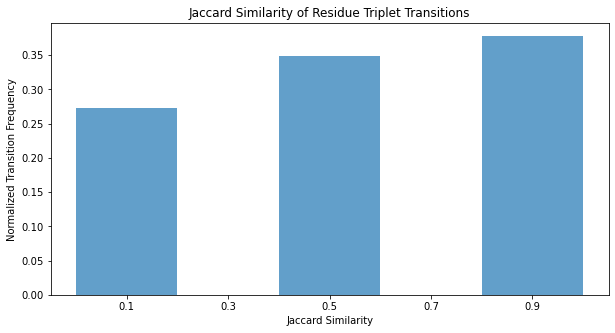

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate Jaccard similarities
def jaccard_similarity(set1, set2):
    return len(set(set1).intersection(set2)) / len(set(set1).union(set2))

jaccard_bins = np.linspace(0, 1, 6)
jaccard_hist = np.zeros(len(jaccard_bins) - 1)

for (from_set, to_set), count in triplet_transitions_sorted.items():
    sim = jaccard_similarity(from_set, to_set)
    bin_idx = np.digitize(sim, jaccard_bins, right=True) - 1
    jaccard_hist[bin_idx] += count

# Normalize and plot
jaccard_hist /= jaccard_hist.sum()

plt.figure(figsize=(10, 5))
plt.bar((jaccard_bins[:-1] + jaccard_bins[1:]) / 2, jaccard_hist, width=0.2, alpha=0.7)
plt.xlabel("Jaccard Similarity")
plt.ylabel("Normalized Transition Frequency")
plt.xticks(np.round((jaccard_bins[:-1] + jaccard_bins[1:]) / 2, 2))
plt.title("Jaccard Similarity of Residue Triplet Transitions")
plt.show()


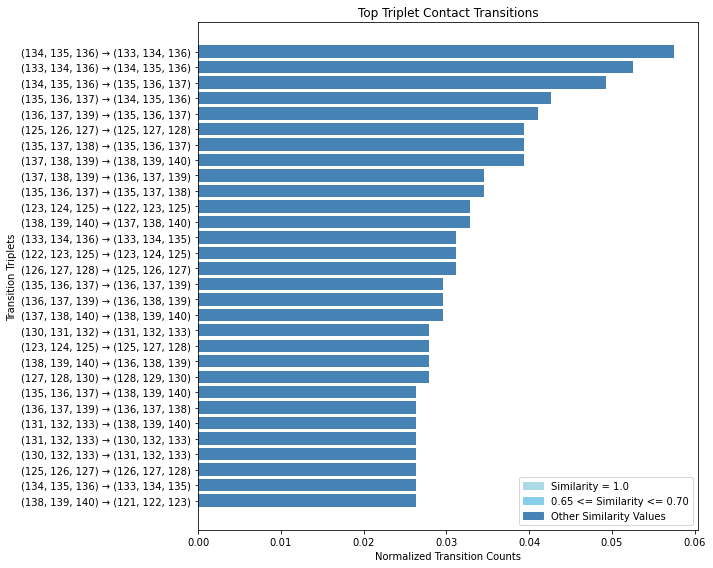

In [8]:
# Group transitions by similarity class
color_map = []
transition_labels = []
transition_counts = []

for (from_set, to_set), count in list(triplet_transitions_sorted.items())[:30]:
    sim = jaccard_similarity(from_set, to_set)
    if sim == 1.0:
        color_map.append("lightblue")
    elif 0.65 <= sim <= 0.70:
        color_map.append("skyblue")
    else:
        color_map.append("steelblue")
    transition_labels.append(f"{from_set} → {to_set}")
    transition_counts.append(count)

# Normalize counts
transition_counts = np.array(transition_counts) / sum(transition_counts)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(transition_labels, transition_counts, color=color_map)
plt.xlabel("Normalized Transition Counts")
plt.ylabel("Transition Triplets")
plt.title("Top Triplet Contact Transitions")
plt.gca().invert_yaxis()
plt.legend(handles=[
    plt.Rectangle((0, 0), 1, 1, color="lightblue", label="Similarity = 1.0"),
    plt.Rectangle((0, 0), 1, 1, color="skyblue", label="0.65 <= Similarity <= 0.70"),
    plt.Rectangle((0, 0), 1, 1, color="steelblue", label="Other Similarity Values")
])
plt.tight_layout()
plt.show()


/var/folders/3s/xgfhtpqj3d31_g5rxc7tttp0g7nxt3/T/ipykernel_51096/4048063898.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=[trans[0] for trans in y_normalized_jac], x=transition_labels, palette=colors)


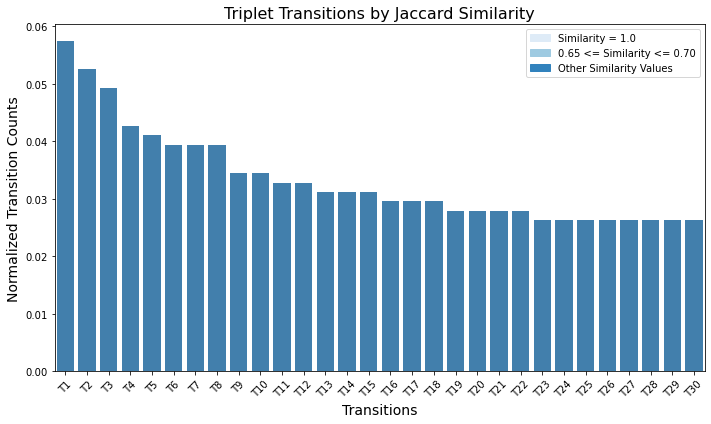

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Step 1: Convert triplet transition dict to list
triplet_items = list(triplet_transitions_sorted.items())[:30]  # top 30 transitions

# Step 2: Compute similarities and normalize counts
x_jac = [(from_set, to_set) for (from_set, to_set), count in triplet_items]
y_jac = [count for (from_set, to_set), count in triplet_items]
total_count = sum(y_jac)
y_normalized_jac = [(count / total_count, (from_set, to_set)) for (from_set, to_set), count in triplet_items]

# Step 3: Assign colors based on similarity
colors = []
for (from_set, to_set), count in triplet_items:
    sim = jaccard_similarity(from_set, to_set)
    if sim == 1.0:
        colors.append("#deebf7")  # light blue
    elif 0.65 <= sim <= 0.70:
        colors.append("#9ecae1")  # medium blue
    else:
        colors.append("#3182bd")  # dark blue

# Step 4: Create transition labels
transition_labels = [f"T{i+1}" for i in range(len(x_jac))]

# Optional: Map T-labels back to triplets if needed later
transition_map = {
    f"T{i+1}": (x_jac[i][0], x_jac[i][1])
    for i in range(len(x_jac))
}

# Step 5: Plot
plt.figure(figsize=(10, 6))
sns.barplot(y=[trans[0] for trans in y_normalized_jac], x=transition_labels, palette=colors)

blue_patch_1 = mpatches.Patch(color="#deebf7", label="Similarity = 1.0")
blue_patch_2 = mpatches.Patch(color="#9ecae1", label="0.65 <= Similarity <= 0.70")
blue_patch_3 = mpatches.Patch(color="#3182bd", label="Other Similarity Values")

plt.legend(handles=[blue_patch_1, blue_patch_2, blue_patch_3])
plt.ylabel('Normalized Transition Counts', fontsize=14)
plt.xlabel('Transitions', fontsize=14)
plt.xticks(rotation=45)
plt.title("Triplet Transitions by Jaccard Similarity", fontsize=16)
plt.tight_layout()
plt.show()
